In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gaiamock import gaiamock_var  as gm
from gaiamock import gaiamock_mod  as gmo
from gaiamock import variability_tool as vt
import pandas as pd
path_to_data="/Users/giulianoiorio/Dropbox/Work_Project/RRLgaiamock/paper/data/healpix_scans/healpix_scans"
gm.set_healpyx_table_path(path_to_data)
gmo.set_healpyx_table_path(path_to_data)

RUWE 0.958883169880601
RUWE 0.9992387151074403


(array([-8., -6., -4., -2.,  0.,  2.,  4.,  6.,  8.]),
 [Text(0, -8.0, '−8'),
  Text(0, -6.0, '−6'),
  Text(0, -4.0, '−4'),
  Text(0, -2.0, '−2'),
  Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8')])

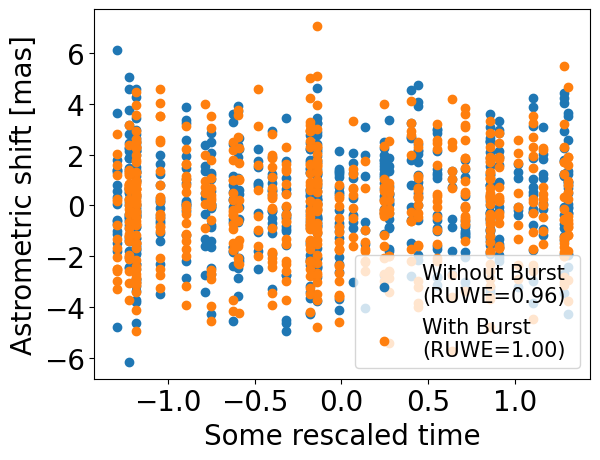

In [47]:
ra=230
dec=35
pmra=0
pmdec=0
parallax=0.2
phot_g_mean_mag=19

#JBDTCB ≈ 2456863.5 to 2459000.5 Gaia DR3 interval 

t,psi,plx, Lambda, error = gmo.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    c_funcs=None
                                   )
ruwe=gmo.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0]
print("RUWE",ruwe)
plt.scatter(t,Lambda,label=f"Without Burst \n(RUWE={ruwe:.2f})")

varmodel=vt.ColorBurst(amp=-1,tpeak=2457363.5,dtrise=5,dtdecay=30,fchrom=2,relative_norm=False)
t,psi,plx, Lambda, error = gmo.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    c_funcs=None,
                                    variability_tool=varmodel
                                   )
ruwe=gmo.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0]
print("RUWE",ruwe)
plt.scatter(t,Lambda,label=f"With Burst\n(RUWE={ruwe:.2f})")
plt.legend(loc="lower right",fontsize=15)
plt.xlabel("Some rescaled time",fontsize=20)
plt.ylabel("Astrometric shift [mas]",fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

